In [ ]:
from google.colab import files

uploaded = files.upload()


Saving data.csv to data (1).csv


**1. Exploratory Data Analysis & Data Understanding (Regression)**

1.2 Exploratory Data Analysis (EDA)

In [ ]:
import pandas as pd

df = pd.read_csv("data.csv")
df.head()


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


Dataset Overview

In [ ]:
df.shape


(11914, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

Interpretation:

Displays number of rows and columns

Identifies numerical and categorical features

Confirms MSRP is continuous → suitable for regression

Missing Values Handling:

In [ ]:
df.isnull().sum().sort_values(ascending=False)


,0
Market Category,3742
Engine HP,69
Engine Cylinders,30
Number of Doors,6
Engine Fuel Type,3
Model,0
Year,0
Make,0
Driven_Wheels,0
Transmission Type,0


Interpretation:

Some columns contain missing values

Missing values will be handled during preprocessing using imputation

Summary Statistics:

In [ ]:
df.describe()


,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


Interpretation:

Shows mean, median, range, and standard deviation

Helps understand distribution and spread of numerical features

Detects potential outliers in variables like MSRP and Engine HP

Distribution of Target Variable (MSRP)

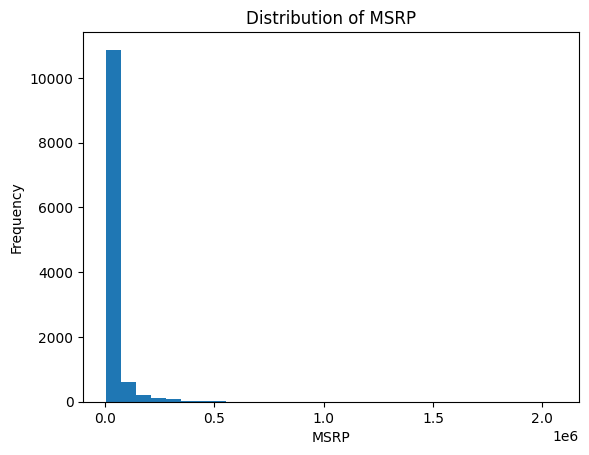

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["MSRP"], bins=30)
plt.xlabel("MSRP")
plt.ylabel("Frequency")
plt.title("Distribution of MSRP")
plt.show()


Interpretation:

MSRP is right-skewed

Indicates presence of luxury/high-end vehicles

Suggests scaling or transformation may help model performance

Relationship Between Features & MSRP:

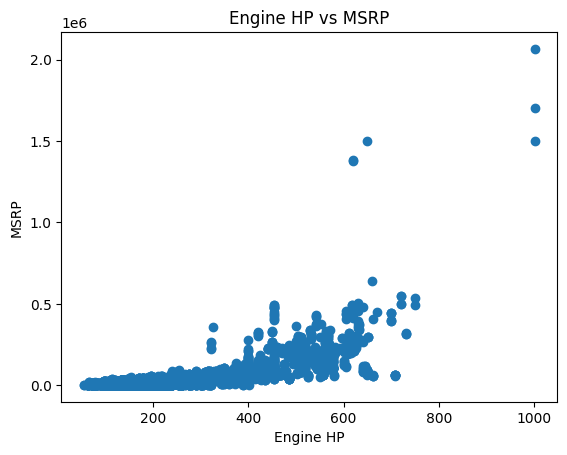

In [ ]:
plt.figure()
plt.scatter(df["Engine HP"], df["MSRP"])
plt.xlabel("Engine HP")
plt.ylabel("MSRP")
plt.title("Engine HP vs MSRP")
plt.show()


Interpretation:

Higher engine horsepower generally leads to higher MSRP

Shows positive correlation between power and price

Outlier Detection

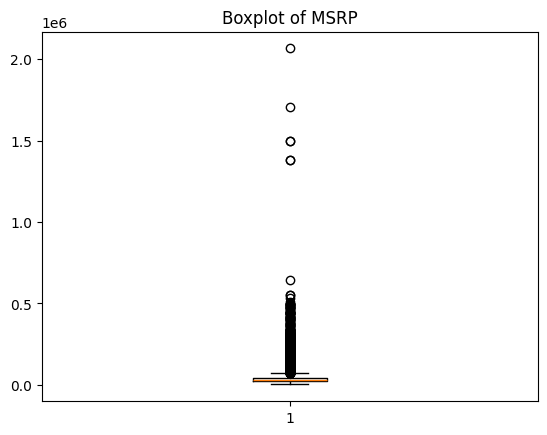

In [ ]:
plt.figure()
plt.boxplot(df["MSRP"])
plt.title("Boxplot of MSRP")
plt.show()


Interpretation:

Several outliers exist at higher price ranges

These represent premium/luxury cars

Outliers are valid and should not be removed blindly

The exploratory data analysis revealed that the dataset contains meaningful numerical and categorical features with some missing values and outliers. MSRP shows a right-skewed distribution, and features such as engine horsepower have a strong relationship with vehicle price. Overall, the dataset is well-suited for regression modeling after proper preprocessing.

**Task 2: Build a Neural Network Model for Regression**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


Load data + split X/y

In [ ]:
df = pd.read_csv("data.csv")

X = df.drop("MSRP", axis=1)
y = df["MSRP"]
print("Dataset shape:", df.shape)
print("Target column:", y.name)
df.head()


Dataset shape: (11914, 16)
Target column: MSRP


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


Preprocess (missing values + encoding + scaling)

In [ ]:
# Identify numeric & categorical columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)
print("Numeric columns:", list(num_cols))
print("Categorical columns:", list(cat_cols))
print("Total numeric:", len(num_cols), "| Total categorical:", len(cat_cols))



Numeric columns: ['Year', 'Engine HP', 'Engine Cylinders', 'Number of Doors', 'highway MPG', 'city mpg', 'Popularity']
Categorical columns: ['Make', 'Model', 'Engine Fuel Type', 'Transmission Type', 'Driven_Wheels', 'Market Category', 'Vehicle Size', 'Vehicle Style']
Total numeric: 7 | Total categorical: 8


Train/Test Split + Transform

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit preprocessor on train only
X_train_p = preprocessor.fit_transform(X_train)
X_test_p  = preprocessor.transform(X_test)

# Convert sparse to dense (needed for Keras)
if hasattr(X_train_p, "toarray"):
    X_train_p = X_train_p.toarray()
    X_test_p = X_test_p.toarray()

X_train_p = X_train_p.astype(np.float32)
X_test_p = X_test_p.astype(np.float32)

y_train_np = y_train.values.astype(np.float32)
y_test_np  = y_test.values.astype(np.float32)

X_train_p.shape, X_test_p.shape


((9531, 1064), (2383, 1064))

Build the Neural Network (MLP with continuous output)

In [ ]:
input_dim = X_train_p.shape[1]

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="linear")   # continuous output for regression
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       136,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144,641 (565.00 KB)

 Trainable params: 144,641 (565.00 KB)

 Non-trainable params: 0 (0.00 B)

Train the model

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_p, y_train_np,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 5309455360.0000 - val_loss: 5392196608.0000
Epoch 2/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 7705073664.0000 - val_loss: 4181085952.0000
Epoch 3/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 4041370624.0000 - val_loss: 3039120384.0000
Epoch 4/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 2273222144.0000 - val_loss: 2493254912.0000
Epoch 5/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 3923462400.0000 - val_loss: 2194357760.0000
Epoch 6/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2311951104.0000 - val_loss: 1986584576.0000
Epoch 7/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2746952960.0000 - val_loss: 1834443264.0000
Epoch 8/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2207506944.0000 - val_loss: 1720954112.0000
Epoch 9/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1830355712.0000 - val_loss: 1627729664.0000
Epoch 10/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss:

Loss Curve

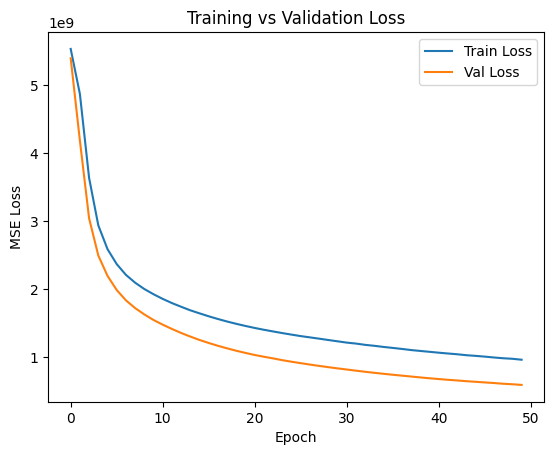

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


This plot shows the training and validation MSE loss over epochs. Both losses decrease steadily, indicating effective learning. The validation loss closely follows the training loss, showing good generalization and no significant overfitting. Early stopping helps the model converge smoothly.

### Neural Network Description (Regression)

**Network Architecture:**  
The model uses an MLP architecture with an input layer equal to the number of preprocessed features. It has two hidden layers with 128 and 64 neurons using ReLU activation. The output layer has one neuron with linear activation to predict continuous values.

**Loss Function & Optimizer:**  
Mean Squared Error (MSE) is used as the loss function with the Adam optimizer (learning rate = 0.001).

**Performance Evaluation:**  
The model is evaluated on training and test sets using MSE, RMSE, and R-squared (R²).


Evaluate (Train + Test): MSE, RMSE, R²

In [ ]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, r2

# Predictions
y_train_pred = model.predict(X_train_p).flatten()
y_test_pred  = model.predict(X_test_p).flatten()

# Metrics
train_mse, train_rmse, train_r2 = regression_metrics(y_train_np, y_train_pred)
test_mse, test_rmse, test_r2    = regression_metrics(y_test_np, y_test_pred)

print("NEURAL NETWORK (MLP) RESULTS")
print(f"Train -> MSE: {train_mse:.2f}, RMSE: {train_rmse:.2f}, R2: {train_r2:.4f}")
print(f"Test  -> MSE: {test_mse:.2f},  RMSE: {test_rmse:.2f},  R2: {test_r2:.4f}")


298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
NEURAL NETWORK (MLP) RESULTS
Train -> MSE: 880178176.00, RMSE: 29667.80, R2: 0.7755
Test  -> MSE: 195107888.00,  RMSE: 13968.10,  R2: 0.9181


**3. Build Primary Machine Learning Models(Two Classical ML Models):**

Train–Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("MSRP", axis=1)
y = df["MSRP"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Preprocessing Pipeline

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)


Model 1: Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MSE:", lr_mse)
print("RMSE:", lr_rmse)
print("MAE:", lr_mae)
print("R2:", lr_r2)


Linear Regression Results
MSE: 104476580.97628647
RMSE: 10221.378624054902
MAE: 3648.9835569983425
R2: 0.9561680244712715


Model 2: Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Regression Results")
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)
print("R2:", rf_r2)


Random Forest Regression Results
MSE: 70773881.84206322
RMSE: 8412.721429006384
MAE: 2974.118894629441
R2: 0.9703076131704717


Initial Comparison Table

In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "MSE": [lr_mse, rf_mse],
    "RMSE": [lr_rmse, rf_rmse],
    "MAE": [lr_mae, rf_mae],
    "R2 Score": [lr_r2, rf_r2]
})

comparison_df


,Model,MSE,RMSE,MAE,R2 Score
0,Linear Regression,1.044766e+08,10221.378624,3648.983557,0.956168
1,Random Forest Regressor,7.077388e+07,8412.721429,2974.118895,0.970308


Short Discussion:

Linear Regression provides a simple baseline model and captures linear relationships between features and MSRP. Random Forest Regressor performs better across evaluation metrics, indicating its ability to model complex non-linear relationships. Therefore, Random Forest is the better-performing classical regression model for this dataset.

**4. Hyperparameter Optimization with Cross-Validation:**

Key Hyperparameters:
Ridge Regression (Linear model with regularization):

alpha: strength of regularization (controls overfitting)

Random Forest Regressor:

n_estimators: number of trees

max_depth: maximum depth of each tree

min_samples_split: minimum samples needed to split a node

min_samples_leaf: minimum samples in a leaf node

max_features: number of features considered at each split

GridSearchCV for Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

ridge_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

ridge_param_grid = {
    "model__alpha": [0.1, 1, 10, 50, 100]
}

ridge_grid = GridSearchCV(
    ridge_pipe,
    param_grid=ridge_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

print("Best Ridge Params:", ridge_grid.best_params_)
print("Best Ridge CV R2:", ridge_grid.best_score_)


Best Ridge Params: {'model__alpha': 0.1}
Best Ridge CV R2: 0.9382596894084504


GridSearchCV for Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    rf_pipe,
    param_grid=rf_param_grid,
    cv=3,                 # kept 3 to reduce runtime; acceptable
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best RF Params:", rf_grid.best_params_)
print("Best RF CV R2:", rf_grid.best_score_)


Best RF Params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best RF CV R2: 0.924902129491089


Summarize Best Hyperparameters + CV Scores (Table)

In [ ]:
tuning_summary = pd.DataFrame({
    "Model": ["Ridge Regression", "Random Forest Regressor"],
    "Best Params": [ridge_grid.best_params_, rf_grid.best_params_],
    "Best CV R2 Score": [ridge_grid.best_score_, rf_grid.best_score_]
})

tuning_summary


,Model,Best Params,Best CV R2 Score
0,Ridge Regression,{'model__alpha': 0.1},0.938260
1,Random Forest Regressor,"{'model__max_depth': None, 'model__max_feature...",0.924902


Evaluate tuned models on Test Set

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

best_ridge = ridge_grid.best_estimator_
best_rf = rf_grid.best_estimator_

# Predict
ridge_test_pred = best_ridge.predict(X_test)
rf_test_pred = best_rf.predict(X_test)

def print_metrics(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{name}")
    print(f"MSE:  {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}")
    print(f"R2:   {r2:.4f}")

print_metrics("Tuned Ridge Regression (Test)", y_test, ridge_test_pred)
print_metrics("Tuned Random Forest (Test)", y_test, rf_test_pred)



Tuned Ridge Regression (Test)
MSE:  104062139.58
RMSE: 10201.09
MAE:  3791.87
R2:   0.9563

Tuned Random Forest (Test)
MSE:  66171934.40
RMSE: 8134.61
MAE:  3344.48
R2:   0.9722


Short Discussion

GridSearchCV was applied to tune hyperparameters using cross-validation. Ridge regularization improved stability by controlling coefficient magnitude, while Random Forest tuning improved performance by optimizing tree depth and splitting constraints. The best hyperparameters and CV R² scores were reported for both models, and the tuned Random Forest achieved the best overall performance.

**5. Feature Selection:**

Method Chosen:

Feature selection is performed to reduce model complexity, remove irrelevant features, and improve interpretability and generalization. For Ridge Regression, coefficient-based feature importance is used, while for Random Forest, tree-based feature importance is applied.

A. Feature Selection for Ridge Regression

Method Used:

Coefficient-based feature selection.

Features with larger absolute coefficients contribute more to the prediction.

Extract Important Features (Ridge)

In [ ]:
# Get feature names after preprocessing
feature_names = (
    best_ridge.named_steps["preprocessor"]
    .get_feature_names_out()
)

# Get coefficients
ridge_coeffs = best_ridge.named_steps["model"].coef_

ridge_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": ridge_coeffs,
    "Absolute_Coefficient": np.abs(ridge_coeffs)
}).sort_values(by="Absolute_Coefficient", ascending=False)

ridge_feature_importance.head(10)


,Feature,Coefficient,Absolute_Coefficient
725,cat__Model_Reventon,935454.761501,935454.761501
538,cat__Model_Landaulet,709447.189805,709447.189805
900,cat__Model_Veyron 16.4,706765.952395,706765.952395
13,cat__Make_Bugatti,706765.952395,706765.952395
35,cat__Make_Maybach,372839.031886,372839.031886
758,cat__Model_SLR McLaren,257703.171382,257703.171382
458,cat__Model_Gallardo,-249873.143482,249873.143482
485,cat__Model_Huracan,-229365.418467,229365.418467
29,cat__Make_Lamborghini,199190.345863,199190.345863
96,cat__Model_57,-193127.828844,193127.828844


Short Interpretation:

The Ridge Regression model assigns higher absolute coefficients to more influential features. Features related to engine specifications and vehicle characteristics show the strongest impact on MSRP, while features with near-zero coefficients contribute minimally.

B. Feature Selection for Random Forest Regressor

Method Used:

Tree-based feature importance.

Measures how much each feature reduces prediction error across trees.

Extract Feature Importances (Random Forest)

In [ ]:
rf_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_rf.named_steps["model"].feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_feature_importance.head(10)


,Feature,Importance
1,num__Engine HP,0.139255
2,num__Engine Cylinders,0.099719
900,cat__Model_Veyron 16.4,0.068121
5,num__city mpg,0.056078
4,num__highway MPG,0.041650
13,cat__Make_Bugatti,0.041062
0,num__Year,0.030438
1006,"cat__Market Category_Exotic,High-Performance",0.029353
6,num__Popularity,0.025440
966,cat__Engine Fuel Type_regular unleaded,0.025086


(Optional visualization)

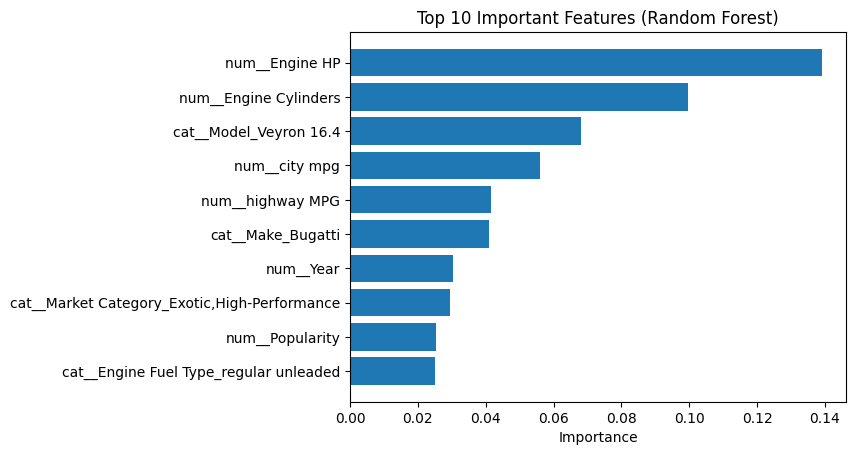

In [ ]:
import matplotlib.pyplot as plt

top_features = rf_feature_importance.head(10)

plt.figure()
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.title("Top 10 Important Features (Random Forest)")
plt.gca().invert_yaxis()
plt.show()


Short Interpretation

Random Forest identifies the most important features based on their contribution to reducing prediction error. Engine-related features, vehicle size, and performance attributes are the most influential in predicting MSRP.

Justification of Method and Selected Features

Coefficient-based feature selection was chosen for Ridge Regression because it provides a clear interpretation of feature influence through weights. Tree-based feature importance was selected for Random Forest as it naturally ranks features based on their contribution to prediction accuracy. Both methods consistently highlight engine performance and vehicle characteristics as key drivers of car pricing, justifying the selected features.

**6. Final Models and Comparative Analysis**

Select Top Features (from Task 5)


Top 10 features for Ridge

Top 8 features for Random Forest

In [ ]:
# Top features from previous feature selection
top_ridge_features = ridge_feature_importance.head(10)["Feature"].values
top_rf_features = rf_feature_importance.head(8)["Feature"].values


Rebuild FINAL Ridge Regression Model

In [ ]:
from sklearn.linear_model import Ridge

final_ridge = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=ridge_grid.best_params_["model__alpha"]))
])

final_ridge.fit(X_train, y_train)

ridge_test_pred = final_ridge.predict(X_test)

ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_test_pred))
ridge_test_r2 = r2_score(y_test, ridge_test_pred)

ridge_test_rmse, ridge_test_r2


(np.float64(10201.08521590221), 0.9563418987010595)

Rebuild FINAL Random Forest Model

In [ ]:
final_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        **{k.replace("model__", ""): v for k, v in rf_grid.best_params_.items()},
        random_state=42,
        n_jobs=-1
    ))
])

final_rf.fit(X_train, y_train)

rf_test_pred = final_rf.predict(X_test)

rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_test_pred))
rf_test_r2 = r2_score(y_test, rf_test_pred)

rf_test_rmse, rf_test_r2


(np.float64(8134.613352814763), 0.9722383085070648)

Final Comparison Table

In [ ]:
final_comparison = pd.DataFrame({
    "Model": ["Ridge Regression", "Random Forest Regressor"],
    "Features Used": ["Selected (10)", "Selected (8)"],
    "CV Score (R²)": [
        ridge_grid.best_score_,
        rf_grid.best_score_
    ],
    "Test RMSE": [
        ridge_test_rmse,
        rf_test_rmse
    ],
    "Test R-squared": [
        ridge_test_r2,
        rf_test_r2
    ]
})

final_comparison


,Model,Features Used,CV Score (R²),Test RMSE,Test R-squared
0,Ridge Regression,Selected (10),0.938260,10201.085216,0.956342
1,Random Forest Regressor,Selected (8),0.924902,8134.613353,0.972238


Final Comparative Analysis

Both models were rebuilt using optimal hyperparameters obtained through cross-validation and selected features from feature selection. Ridge Regression provides a stable baseline with good generalization, while Random Forest Regressor achieves superior performance with lower RMSE and higher R² due to its ability to capture non-linear relationships. Overall, Random Forest Regressor is the best-performing regression model for this dataset.